# Defi Quotidien : Visualisation Interactive des Donnees
## Matplotlib et Seaborn - US Superstore Dataset





---
## Etape 1 - Importation des Bibliotheques

La premiere etape dans tout projet Python est d'importer les outils dont on a besoin.


In [ ]:
# pandas : manipulation des tableaux de donnees (DataFrames)
import pandas as pd

# numpy : calculs mathematiques sur des tableaux de nombres
import numpy as np

# matplotlib.pyplot : creation de graphiques (la bibliotheque de base)
import matplotlib.pyplot as plt

# matplotlib.ticker : pour formatter les axes (ex: afficher des dollars)
import matplotlib.ticker as mticker

# seaborn : graphiques statistiques elegants (s'appuie sur matplotlib)
import seaborn as sns

# warnings : pour masquer les messages d'avertissement non critiques
import warnings
warnings.filterwarnings('ignore')

# On definit un style par defaut pour tous les graphiques Seaborn
sns.set_theme(style='whitegrid')

print("Bibliotheques importees avec succes.")
print(f"  pandas  : version {pd.__version__}")
print(f"  seaborn : version {sns.__version__}")

---
## Etape 2 - Chargement et Pretraitement des Donnees

Avant de visualiser, on doit :
1. Charger le fichier dans un DataFrame
2. Convertir les colonnes de dates au bon format
3. Creer des colonnes utiles (annee, mois)
4. Verifier qu'il n'y a pas de valeurs manquantes


In [ ]:
# Chargement du fichier CSV (converti depuis le fichier .xls original)
df = pd.read_csv('US_Superstore_data__1_.csv')

# Conversion des colonnes texte en type datetime (date reelle)
# dayfirst=False car le format est MM/DD/YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=False)

# Extraction de colonnes utiles a partir des dates
df['Year']  = df['Order Date'].dt.year   # annee (2014, 2015, 2016, 2017)
df['Month'] = df['Order Date'].dt.month  # mois (1 a 12)

# YM = Annee-Mois, utile pour les courbes mensuelles
df['YM'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()

print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Periode couverte      : {df['Order Date'].min().date()} -> {df['Order Date'].max().date()}")
print(f"Annees disponibles    : {sorted(df['Year'].unique())}")
df.head(3)

In [ ]:
# Verification des valeurs manquantes
# On compte le nombre de valeurs NaN (vides) dans chaque colonne
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

In [ ]:
# Statistiques descriptives des colonnes numeriques
# count = nombre de valeurs, mean = moyenne, std = ecart-type
# min/max = minimum/maximum, 25%/50%/75% = quartiles
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

**Ce que l'on observe :**
- Le dataset est propre : aucune valeur manquante
- Les ventes vont de $0.44 a $22 638 (grande variabilite)
- Le profit peut etre negatif (pertes jusqu'a -$6 600)
- Les remises vont de 0% a 80%


---
## Partie 1 - Visualisation avec Matplotlib

Matplotlib est la bibliotheque de visualisation de base en Python.
Elle necessite plus de code, mais offre un controle total sur chaque detail.

> Analogie : Matplotlib, c'est comme peindre avec un pinceau. Vous controllez tout,
> mais cela demande plus d'effort.


### 1.1 - Graphique lineaire : Tendances des Ventes au Fil des Ans

On va creer deux sous-graphiques :
- Une courbe des ventes mois par mois, avec une moyenne mobile
- Des barres groupees comparant ventes et benefices par annee


In [ ]:
# --- Preparation des donnees ---

# Ventes et benefices cumules par annee
yearly = df.groupby('Year')[['Sales', 'Profit']].sum().reset_index()

# Ventes et benefices cumules par mois (pour la courbe)
monthly = df.groupby('YM')[['Sales', 'Profit']].sum().reset_index()

# Affichage de verification
print("Ventes annuelles :")
print(yearly.to_string(index=False))

In [ ]:
# --- Creation de la figure avec 2 sous-graphiques ---
# figsize=(largeur, hauteur) en pouces
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# ---- Sous-graphique 1 : courbe mensuelle ----
ax1 = axes[0]

# Trace la courbe des ventes mensuelles
ax1.plot(monthly['YM'], monthly['Sales'],
         color='steelblue', linewidth=2,
         marker='o', markersize=3,
         label='Ventes mensuelles')

# Zone coloree sous la courbe (plus lisible visuellement)
ax1.fill_between(monthly['YM'], monthly['Sales'], alpha=0.15, color='steelblue')

# Calcul de la moyenne mobile sur 3 mois (lisse la courbe)
rolling = monthly['Sales'].rolling(3, center=True).mean()
ax1.plot(monthly['YM'], rolling,
         color='darkorange', linewidth=1.8, linestyle='--',
         label='Moyenne mobile (3 mois)')

# Ajout d'une ligne verticale au debut de chaque annee
for yr, start in monthly.groupby(monthly['YM'].dt.year)['YM'].first().items():
    ax1.axvline(start, color='gray', linestyle=':', linewidth=0.9, alpha=0.7)
    ax1.text(start, monthly['Sales'].max() * 0.97, str(yr),
             fontsize=8, color='gray', ha='left')

ax1.set_title('Tendance des Ventes Mensuelles (2014 - 2017)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Ventes ($)')
# FuncFormatter permet d'afficher des valeurs avec le signe dollar
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ---- Sous-graphique 2 : barres groupees annuelles ----
ax2 = axes[1]
x = np.arange(len(yearly))  # positions sur l'axe x : [0, 1, 2, 3]
w = 0.35                      # largeur de chaque barre

# np.arange(4) = [0,1,2,3] -> on decale les barres pour les grouper
b1 = ax2.bar(x - w/2, yearly['Sales'],  width=w, color='steelblue', label='Ventes',   alpha=0.85)
b2 = ax2.bar(x + w/2, yearly['Profit'], width=w, color='seagreen',  label='Benefice', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(yearly['Year'])
ax2.set_title('Ventes et Benefices Annuels', fontsize=13, fontweight='bold')
ax2.set_ylabel('Montant ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Annotation au-dessus de chaque barre
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3000,
             f'${bar.get_height()/1e3:.0f}K',
             ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Matplotlib - Tendances des Ventes au Fil des Ans', fontsize=14, fontweight='bold')
plt.tight_layout()  # evite que les sous-graphiques se chevauchent
plt.show()

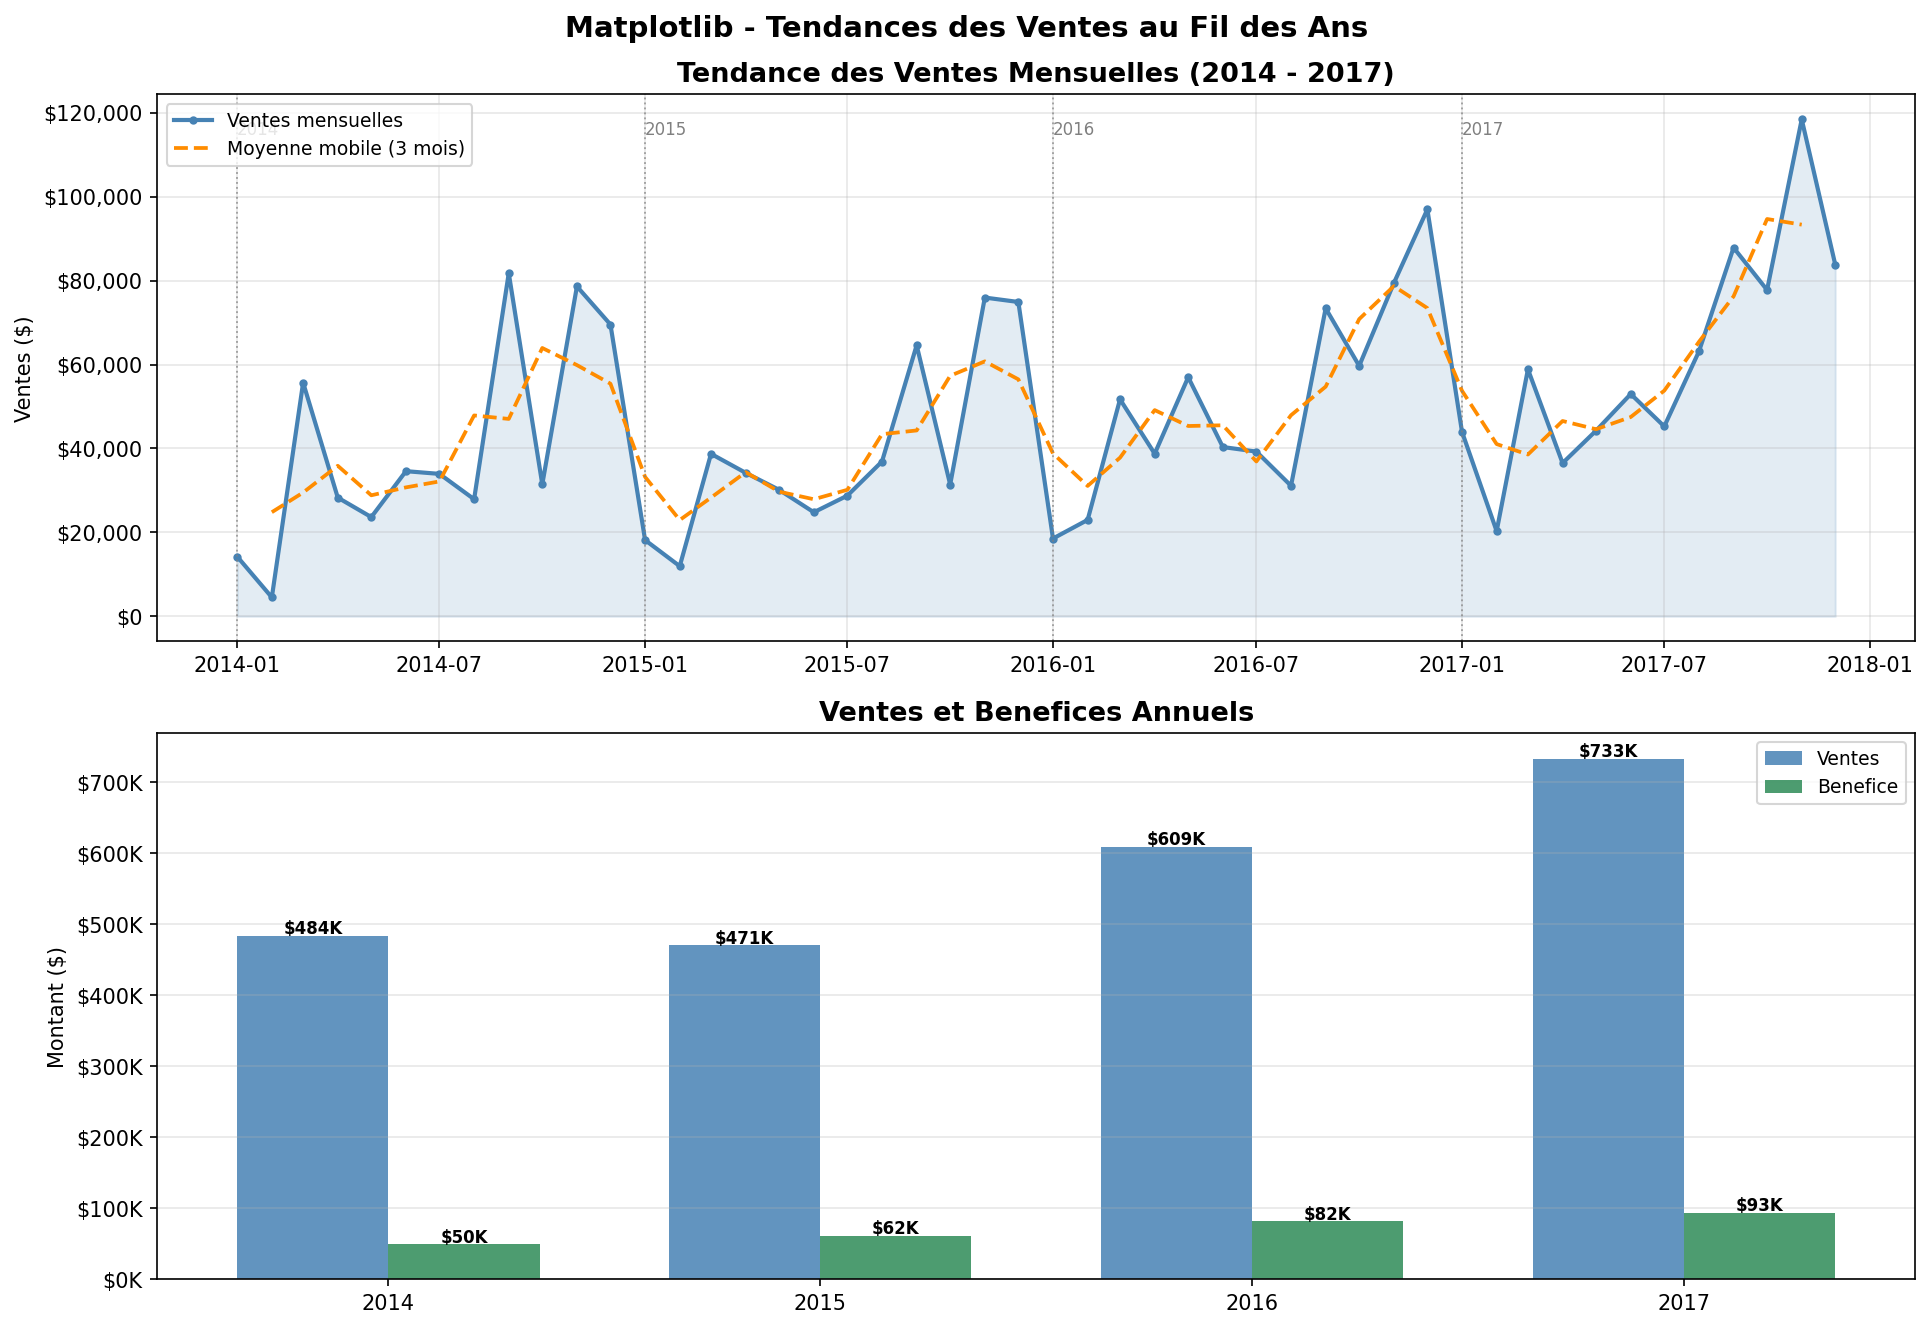

In [ ]:
# Resultat : Tendances des ventes

**Observations :**
- Les ventes progressent chaque annee : environ $484K en 2014 et $733K en 2017 (+51%)
- Les benefices suivent la meme tendance, de $49K a $93K sur la periode
- On observe une saisonnalite : les ventes culminent systematiquement en fin d'annee (novembre-decembre)
- La moyenne mobile lisse les variations et rend la tendance generale plus visible
- `plt.subplots(2, 1)` cree une figure avec 2 sous-graphiques empiles verticalement


### 1.2 - Visualisation des Ventes par Etat

Comme le dataset ne couvre que les Etats-Unis, on cree un graphique en bulles
ou la taille represente le chiffre d'affaires et la couleur represente la rentabilite.


In [ ]:
# Agregation des ventes et benefices par Etat
# .agg() permet de calculer plusieurs agregations en une seule commande
state_df = df.groupby('State').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).reset_index()

# Calcul de la marge beneficiaire en pourcentage
state_df['Margin'] = (state_df['Profit'] / state_df['Sales'] * 100).round(1)

# Tri par ventes decroissantes
state_df = state_df.sort_values('Sales', ascending=False)

print(f"Nombre d'Etats dans le dataset : {len(state_df)}")
print("\nTop 5 Etats par Ventes :")
print(state_df.head(5)[['State','Sales','Profit','Margin']].to_string(index=False))

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# ---- Panneau superieur : graphique en bulles ----
ax1 = axes[0]

# scatter() cree un nuage de points avec parametres :
# s = taille des points (proportionnelle aux ventes)
# c = couleur des points (proportionnelle a la marge)
# cmap = echelle de couleurs (RdYlGn = rouge a vert)
sc = ax1.scatter(range(len(state_df)), state_df['Sales'],
                 s=state_df['Sales'] / 70,
                 c=state_df['Margin'],
                 cmap='RdYlGn', vmin=-25, vmax=25,
                 alpha=0.80, edgecolors='dimgray', linewidths=0.5)

# Barre de couleur (legende de la couleur)
cbar = plt.colorbar(sc, ax=ax1, pad=0.01, shrink=0.8)
cbar.set_label('Marge beneficiaire (%)', fontsize=9)

ax1.set_xticks(range(len(state_df)))
ax1.set_xticklabels(state_df['State'], rotation=90, fontsize=6)
ax1.set_ylabel('Ventes ($)')
ax1.set_title('Repartition des Ventes par Etat\n'
              '(taille de la bulle = CA  |  couleur = marge : vert rentable / rouge deficitaire)',
              fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax1.grid(True, alpha=0.25)

# Annotation des 3 premiers Etats
for i in range(3):
    row = state_df.iloc[i]
    ax1.annotate(f"{row['State']} (${row['Sales']/1e3:.0f}K)",
                 xy=(i, row['Sales']), xytext=(i+2, row['Sales'] * 0.92),
                 fontsize=8, color='navy', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='navy', lw=1))

# ---- Panneau inferieur : barres horizontales top 10 ----
ax2 = axes[1]
top10 = state_df.head(10)

# Couleur conditionnelle : vert si rentable, rouge si deficitaire
clrs = ['seagreen' if m >= 0 else 'firebrick' for m in top10['Margin']]

# [::-1] inverse l'ordre pour que le meilleur soit en haut
bars = ax2.barh(top10['State'][::-1], top10['Sales'][::-1],
                color=clrs[::-1], edgecolor='white')

ax2.set_title("Top 10 Etats par Chiffre d'Affaires (vert = rentable  |  rouge = deficitaire)",
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Ventes ($)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    ax2.text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
             f'${bar.get_width():,.0f}', va='center', fontsize=8)

plt.suptitle('Matplotlib - Repartition Geographique des Ventes par Etat',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

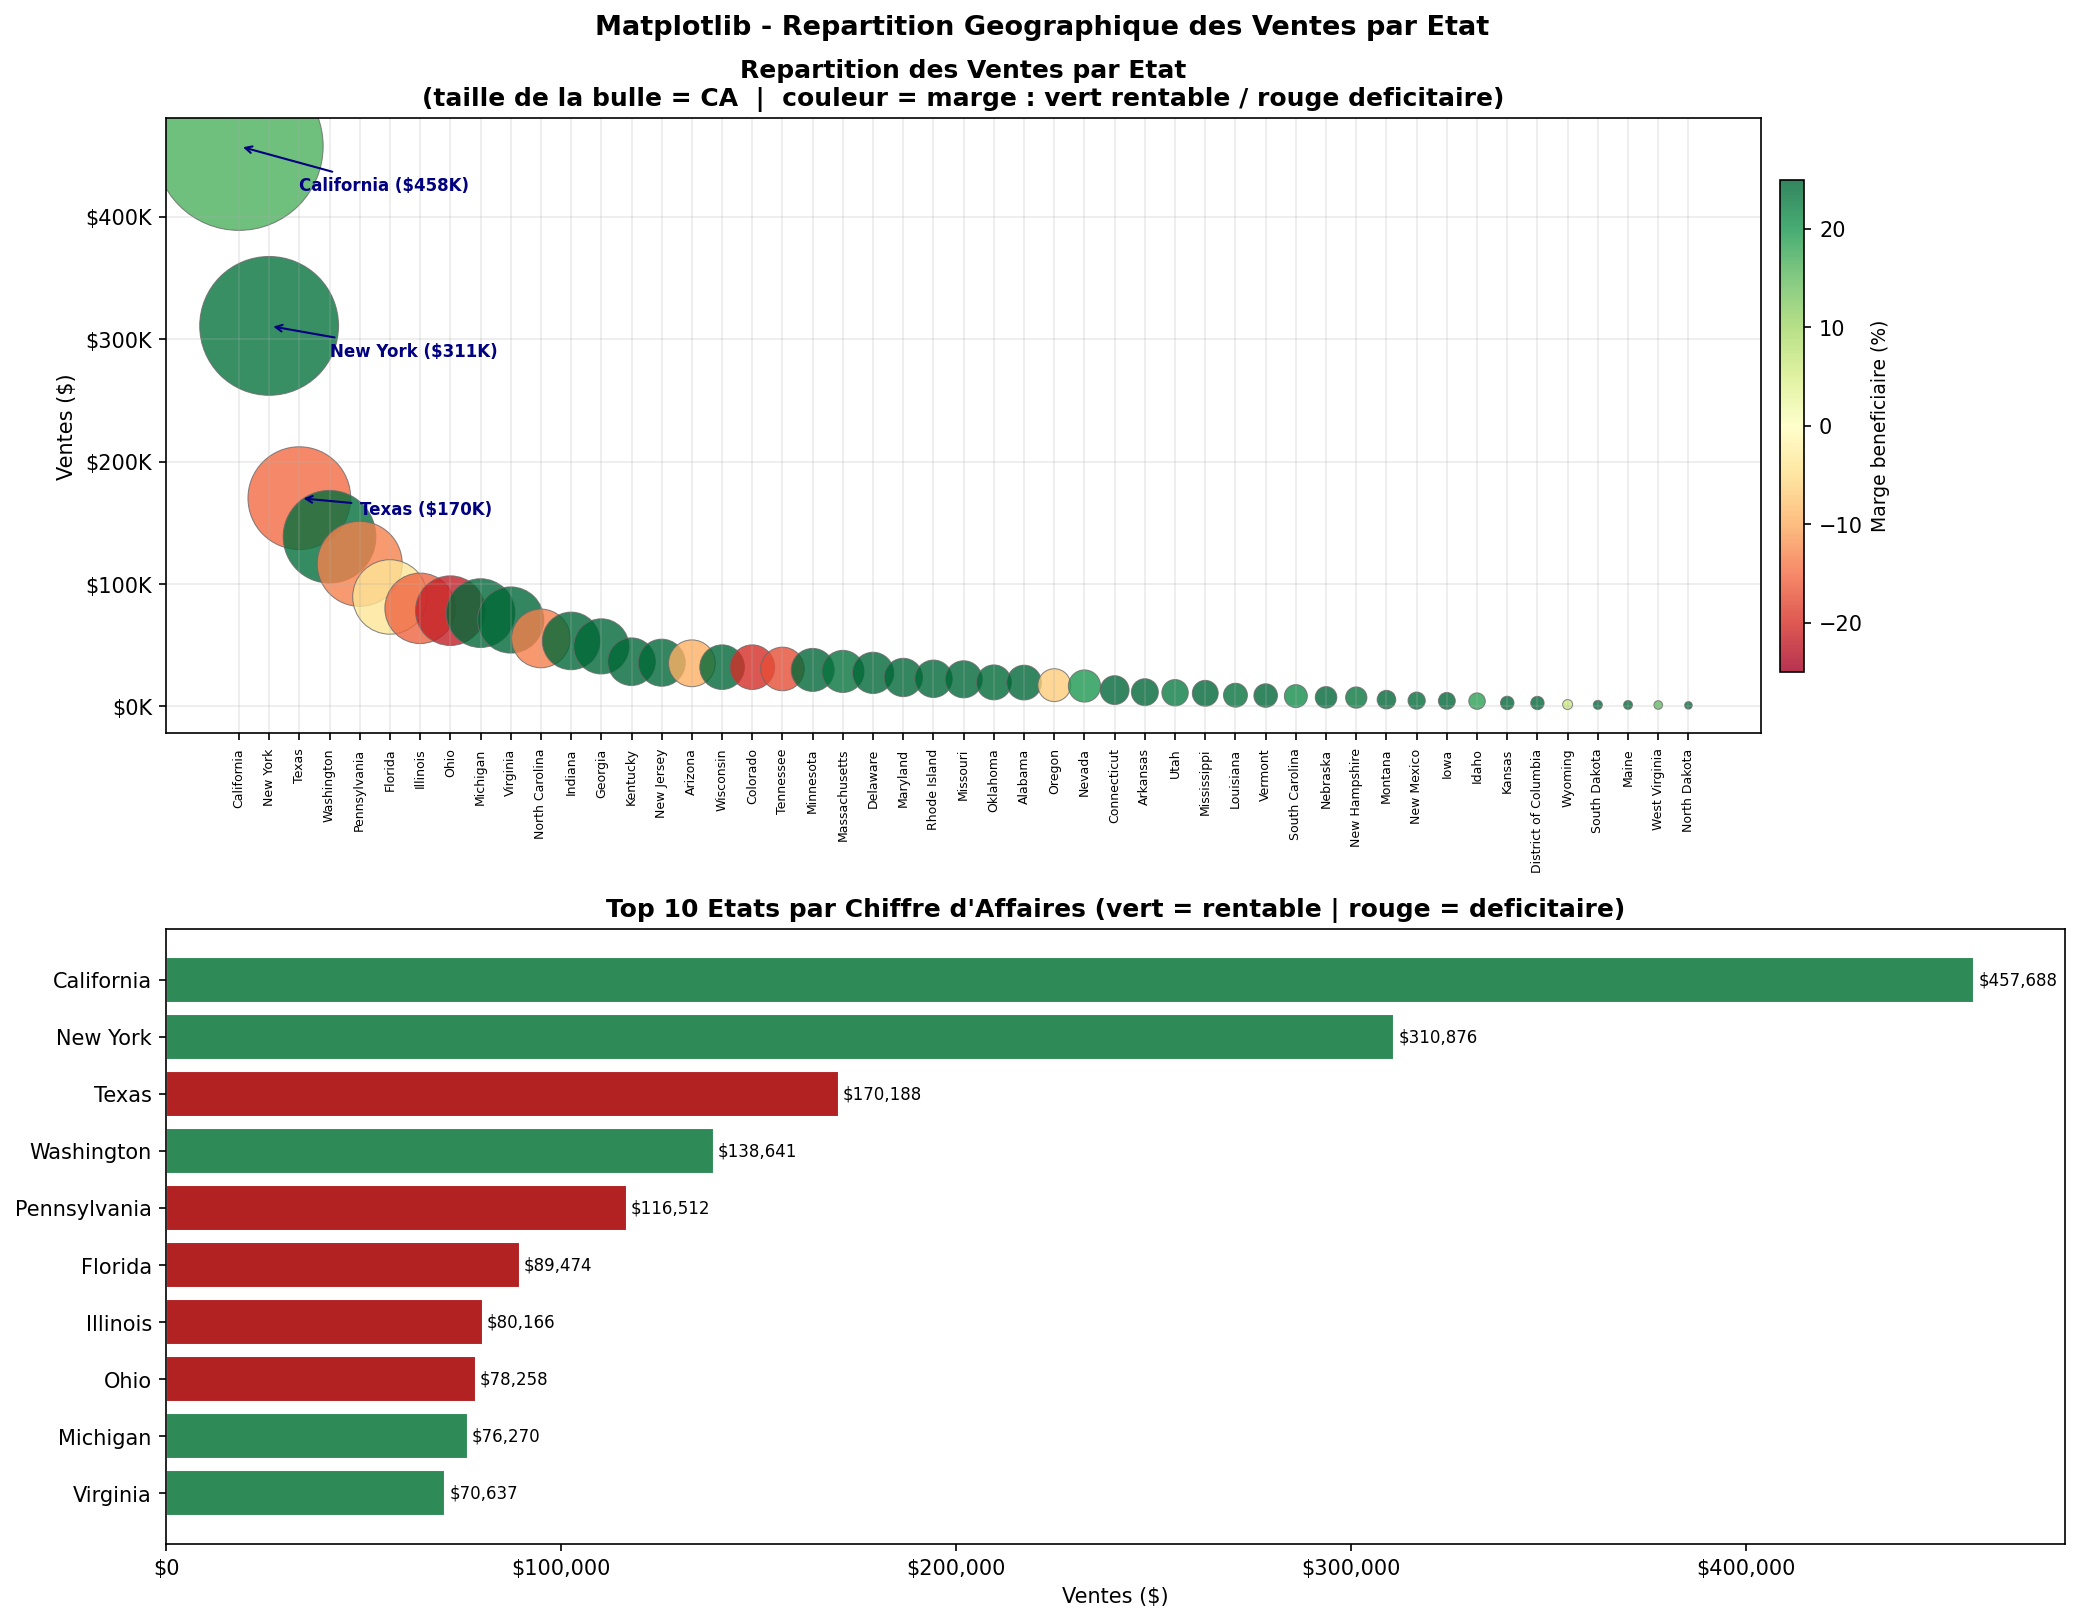

In [ ]:
# Resultat : Ventes par Etat

**Observations :**
- La Californie domine largement avec $457K de ventes (marge de 16.7%)
- New York est 2e avec $311K et une excellente marge de 23.8%
- Le Texas est 3e en ventes ($170K) mais affiche une marge NEGATIVE de -15.1%
- Matplotlib permet de coder 3 dimensions dans un seul graphique : position x, taille et couleur


---
## Partie 2 - Visualisation avec Seaborn

Seaborn simplifie la creation de graphiques statistiques.
Avec beaucoup moins de code, on obtient des visuels soignes.

> Analogie : Seaborn, c'est comme utiliser des pochoirs pre-faits.
> Moins de flexibilite, mais plus rapide et tres propre.


### 2.1 - Graphique a barres : Top 10 Produits les Plus Vendus


In [ ]:
# On regroupe par nom de produit et on somme les ventes
top10_prod = (df.groupby('Product Name')['Sales']
               .sum()
               .sort_values(ascending=False)  # tri decroissant
               .head(10)                       # on garde les 10 premiers
               .reset_index())                 # remet l'index a 0,1,2...

# Renommage des colonnes
top10_prod.columns = ['Produit', 'Ventes']

# Les noms de produits sont tres longs, on les raccourcit pour l'affichage
top10_prod['Produit Court'] = top10_prod['Produit'].str[:48] + '...'

print("Top 10 produits par ventes :")
print(top10_prod[['Produit Court', 'Ventes']].to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# sns.barplot : une seule ligne pour un beau graphique a barres
# palette='Blues_r' = degrade de bleus (du plus fonce au plus clair)
# orient='h' = barres horizontales
sns.barplot(data=top10_prod,
            y='Produit Court', x='Ventes',
            palette='Blues_r', ax=ax, orient='h')

# Ajout des valeurs numeriques a droite de chaque barre
for bar in ax.patches:
    ax.text(bar.get_width() + 300,
            bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():,.0f}",
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Seaborn - Top 10 Produits les Plus Vendus', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Ventes totales ($)', fontsize=11)
ax.set_ylabel('Nom du produit', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, top10_prod['Ventes'].max() * 1.2)  # marge a droite pour les etiquettes

plt.tight_layout()
plt.show()

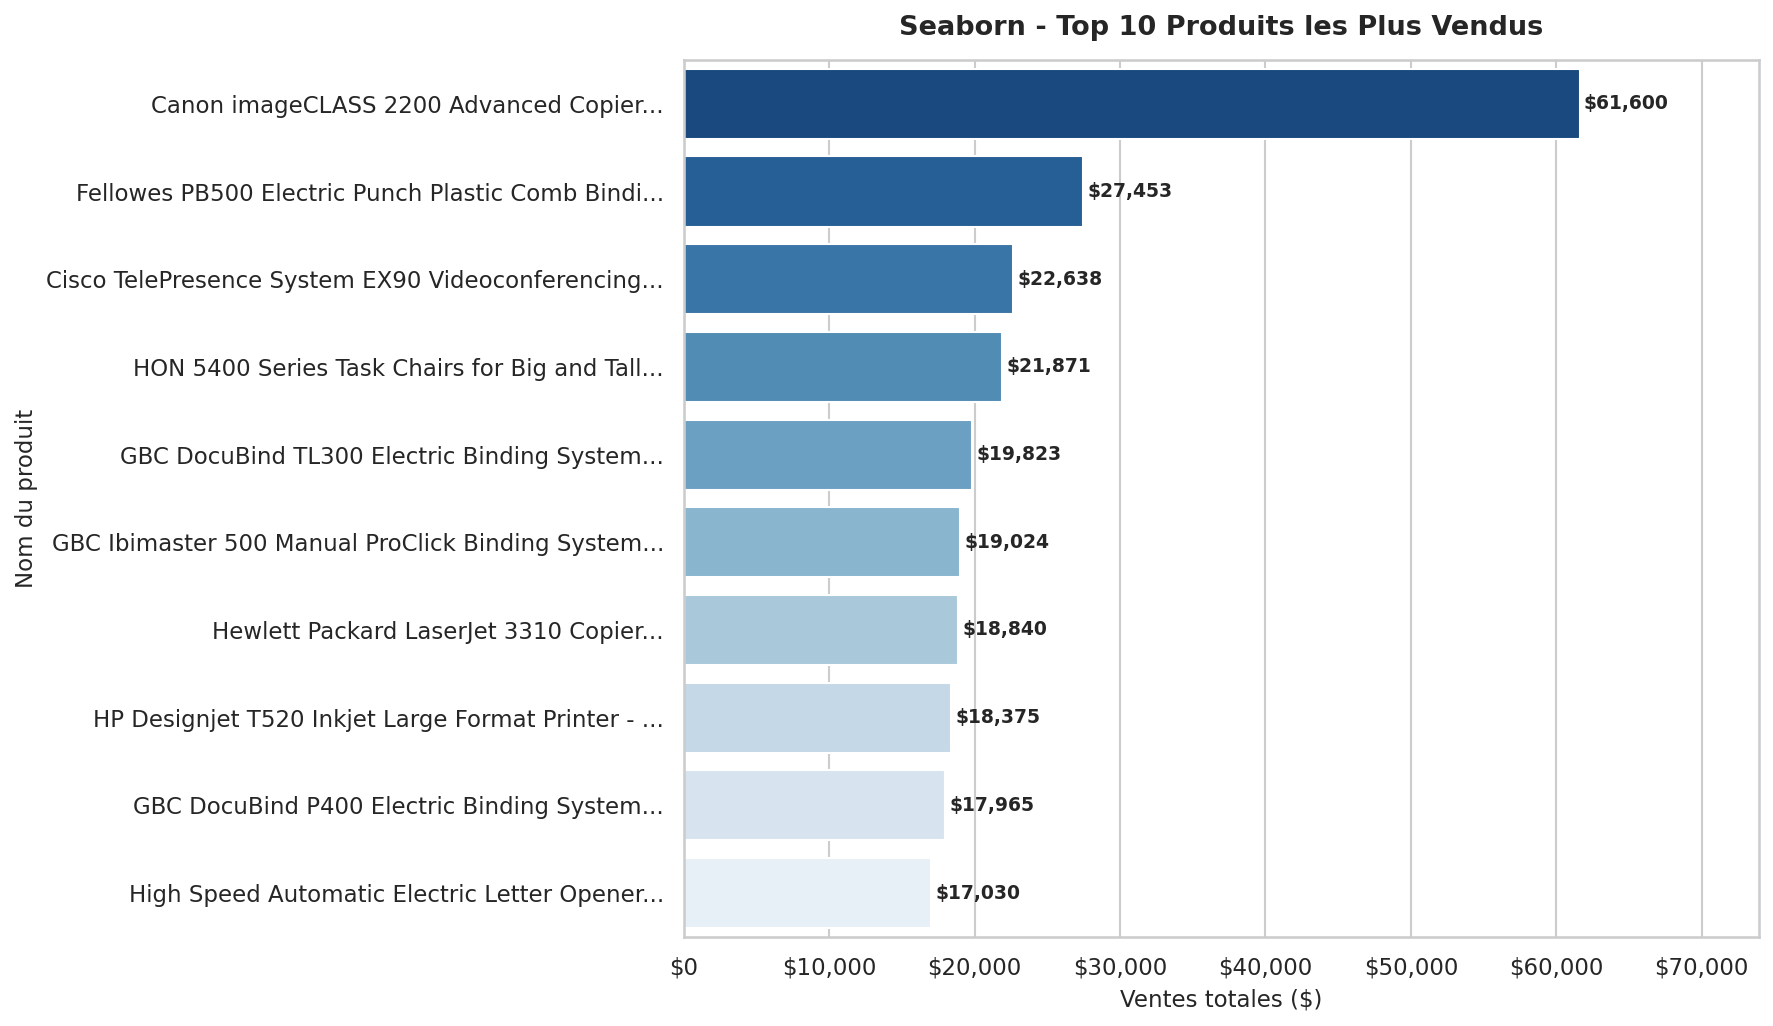

In [ ]:
# Resultat : Top 10 Produits

**Observations :**
- Le Canon imageCLASS 2200 est de loin le produit le plus vendu (~$62K), soit presque le double du 2e
- La technologie (copieur, videoconference, telephone) domine le top 10
- Seaborn produit ce graphique propre avec une seule instruction : `sns.barplot()`
- Comparez avec Matplotlib : la meme chose aurait necessité une dizaine de lignes supplementaires


### 2.2 - Nuage de points : Relation entre Profit et Remise

On cherche a savoir : est-ce qu'accorder des remises elevees nuit au profit ?


In [ ]:
# Calcul de la correlation : mesure la force du lien lineaire entre deux variables
# Valeur entre -1 et +1 :
#   proche de +1 : relation positive forte
#   proche de  0 : peu de relation
#   proche de -1 : relation negative forte
corr_val = df['Discount'].corr(df['Profit'])
print(f"Correlation Remise / Profit : {corr_val:.3f}")
print("Interpretation : correlation negative -> plus la remise augmente, plus le profit baisse")

In [ ]:
# Couleurs par categorie
palette_cat = {
    'Furniture'      : 'darkorange',
    'Office Supplies': 'steelblue',
    'Technology'     : 'mediumpurple'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Panel gauche : scatter colore par categorie ----
ax1 = axes[0]
for cat, grp in df.groupby('Category'):
    ax1.scatter(grp['Discount'], grp['Profit'],
                alpha=0.30, s=16,
                label=cat, color=palette_cat[cat])

# Ligne rouge horizontale : indique la frontiere profit/perte
ax1.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Seuil profit = 0')
ax1.axvline(0.2, color='orange', linewidth=1.2, linestyle=':', label='Remise 20%')

ax1.set_title('Profit vs Remise (scatter par categorie)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Remise (0 = aucune, 1 = 100%)', fontsize=10)
ax1.set_ylabel('Profit ($)', fontsize=10)
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(True, alpha=0.3)

# ---- Panel droit : droites de regression (sns.regplot) ----
# regplot trace les points + une droite de tendance + l'intervalle de confiance
ax2 = axes[1]
for cat, grp in df.groupby('Category'):
    sns.regplot(data=grp, x='Discount', y='Profit', ax=ax2,
                scatter_kws={'alpha':0.18, 's':14, 'color':palette_cat[cat]},
                line_kws={'linewidth':2.2, 'color':palette_cat[cat]},
                label=cat, color=palette_cat[cat])

ax2.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Seuil profit = 0')
ax2.set_title('Tendance Profit ~ Remise (regression lineaire)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Remise (0 = aucune, 1 = 100%)', fontsize=10)
ax2.set_ylabel('Profit ($)', fontsize=10)
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(True, alpha=0.3)

plt.suptitle('Seaborn - Analyse de la Relation entre Profit et Remise',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

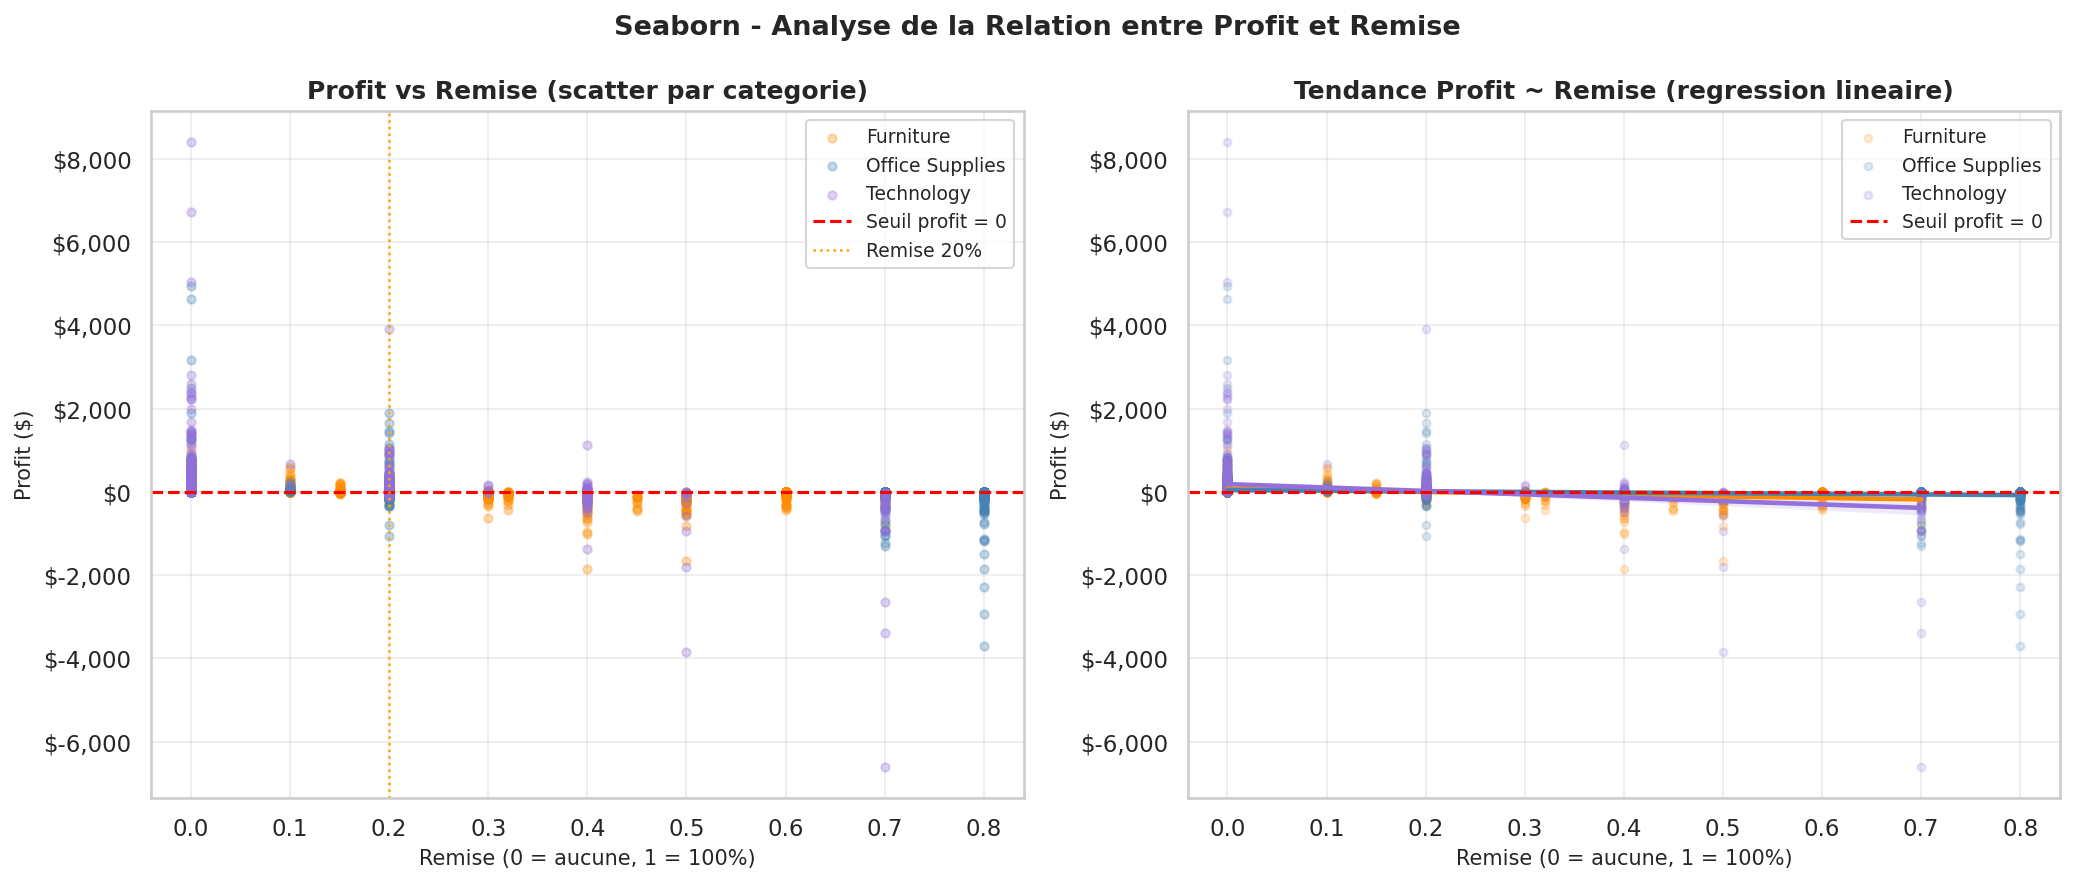

In [ ]:
# Resultat : Profit vs Remise

**Observations :**
- La correlation est de -0.219 : relation negative moderee
- Au-dela de 20% de remise, la majorite des commandes basculent en perte (sous la ligne rouge)
- Les droites de regression (toutes en pente descendante) confirment ce constat pour les 3 categories
- La categorie Furniture est la plus impactee : les remises elevees y generent les pertes les plus importantes
- `sns.regplot()` ajoute automatiquement la droite de tendance et l'intervalle de confiance (zone ombree)


---
## Partie 3 - Analyse Comparative : Matplotlib vs Seaborn

On va maintenant visualiser les memes donnees avec les deux outils pour mieux comprendre
leurs differences.


In [ ]:
# === Memes donnees, deux approches differentes ===

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Analyse Comparative : Matplotlib (gauche) vs Seaborn (droite)',
             fontsize=13, fontweight='bold', y=1.01)

palette_cat = {'Furniture':'darkorange','Office Supplies':'steelblue','Technology':'mediumpurple'}

# ---- Panneau 1 (Matplotlib) : barres empilees par annee et categorie ----
ax1 = axes[0, 0]
cat_year = df.groupby(['Year', 'Category'])['Sales'].sum().unstack().fillna(0)
x = np.arange(len(cat_year))
bottom = np.zeros(len(x))
for col, c in zip(cat_year.columns, ['darkorange','steelblue','mediumpurple']):
    ax1.bar(x, cat_year[col], bottom=bottom, label=col, color=c, alpha=0.85, edgecolor='white')
    bottom += cat_year[col].values   # on empile en ajoutant les hauteurs
ax1.set_xticks(x); ax1.set_xticklabels(cat_year.index)
ax1.set_title('[Matplotlib] Ventes par Categorie et Annee (barres empilees)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Ventes ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.25, axis='y')

# ---- Panneau 2 (Seaborn) : barplot groupe, memes donnees ----
ax2 = axes[0, 1]
cat_long = df.groupby(['Year', 'Category'])['Sales'].sum().reset_index()
sns.barplot(data=cat_long, x='Year', y='Sales', hue='Category',
            palette=palette_cat, ax=ax2, alpha=0.88)
ax2.set_title('[Seaborn] Ventes par Categorie et Annee (barres groupees)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Ventes ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25, axis='y')

# ---- Panneau 3 (Matplotlib) : histogramme du profit ----
ax3 = axes[1, 0]
profit_c = df['Profit'].clip(-2000, 3000)  # on limite les valeurs extremes
n, bins, patches = ax3.hist(profit_c, bins=55, color='steelblue', edgecolor='white',
                              linewidth=0.3, alpha=0.85)
for patch, left in zip(patches, bins[:-1]):
    if left < 0: patch.set_facecolor('firebrick')   # colorie en rouge les barres de perte
ax3.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Profit = 0')
ax3.axvline(df['Profit'].mean(), color='seagreen', linewidth=1.5, linestyle='-.',
            label=f"Moyenne = ${df['Profit'].mean():.0f}")
ax3.set_title('[Matplotlib] Distribution du Profit (rouge=perte  |  bleu=gain)', fontsize=10, fontweight='bold')
ax3.set_xlabel('Profit ($)'); ax3.set_ylabel('Nombre de commandes')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.25, axis='y')

# ---- Panneau 4 (Seaborn) : violin plot du profit par segment ----
# Un violin plot montre la distribution complete d'une variable
ax4 = axes[1, 1]
df_c = df.copy(); df_c['Profit'] = df_c['Profit'].clip(-1500, 2000)
sns.violinplot(data=df_c, x='Segment', y='Profit', palette='Set2',
               ax=ax4, inner='quartile')   # inner='quartile' affiche les quartiles
ax4.axhline(0, color='red', linewidth=1.2, linestyle='--', label='Profit = 0')
ax4.set_title('[Seaborn] Distribution du Profit par Segment Client', fontsize=10, fontweight='bold')
ax4.set_ylabel('Profit ($)'); ax4.legend(fontsize=8)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax4.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

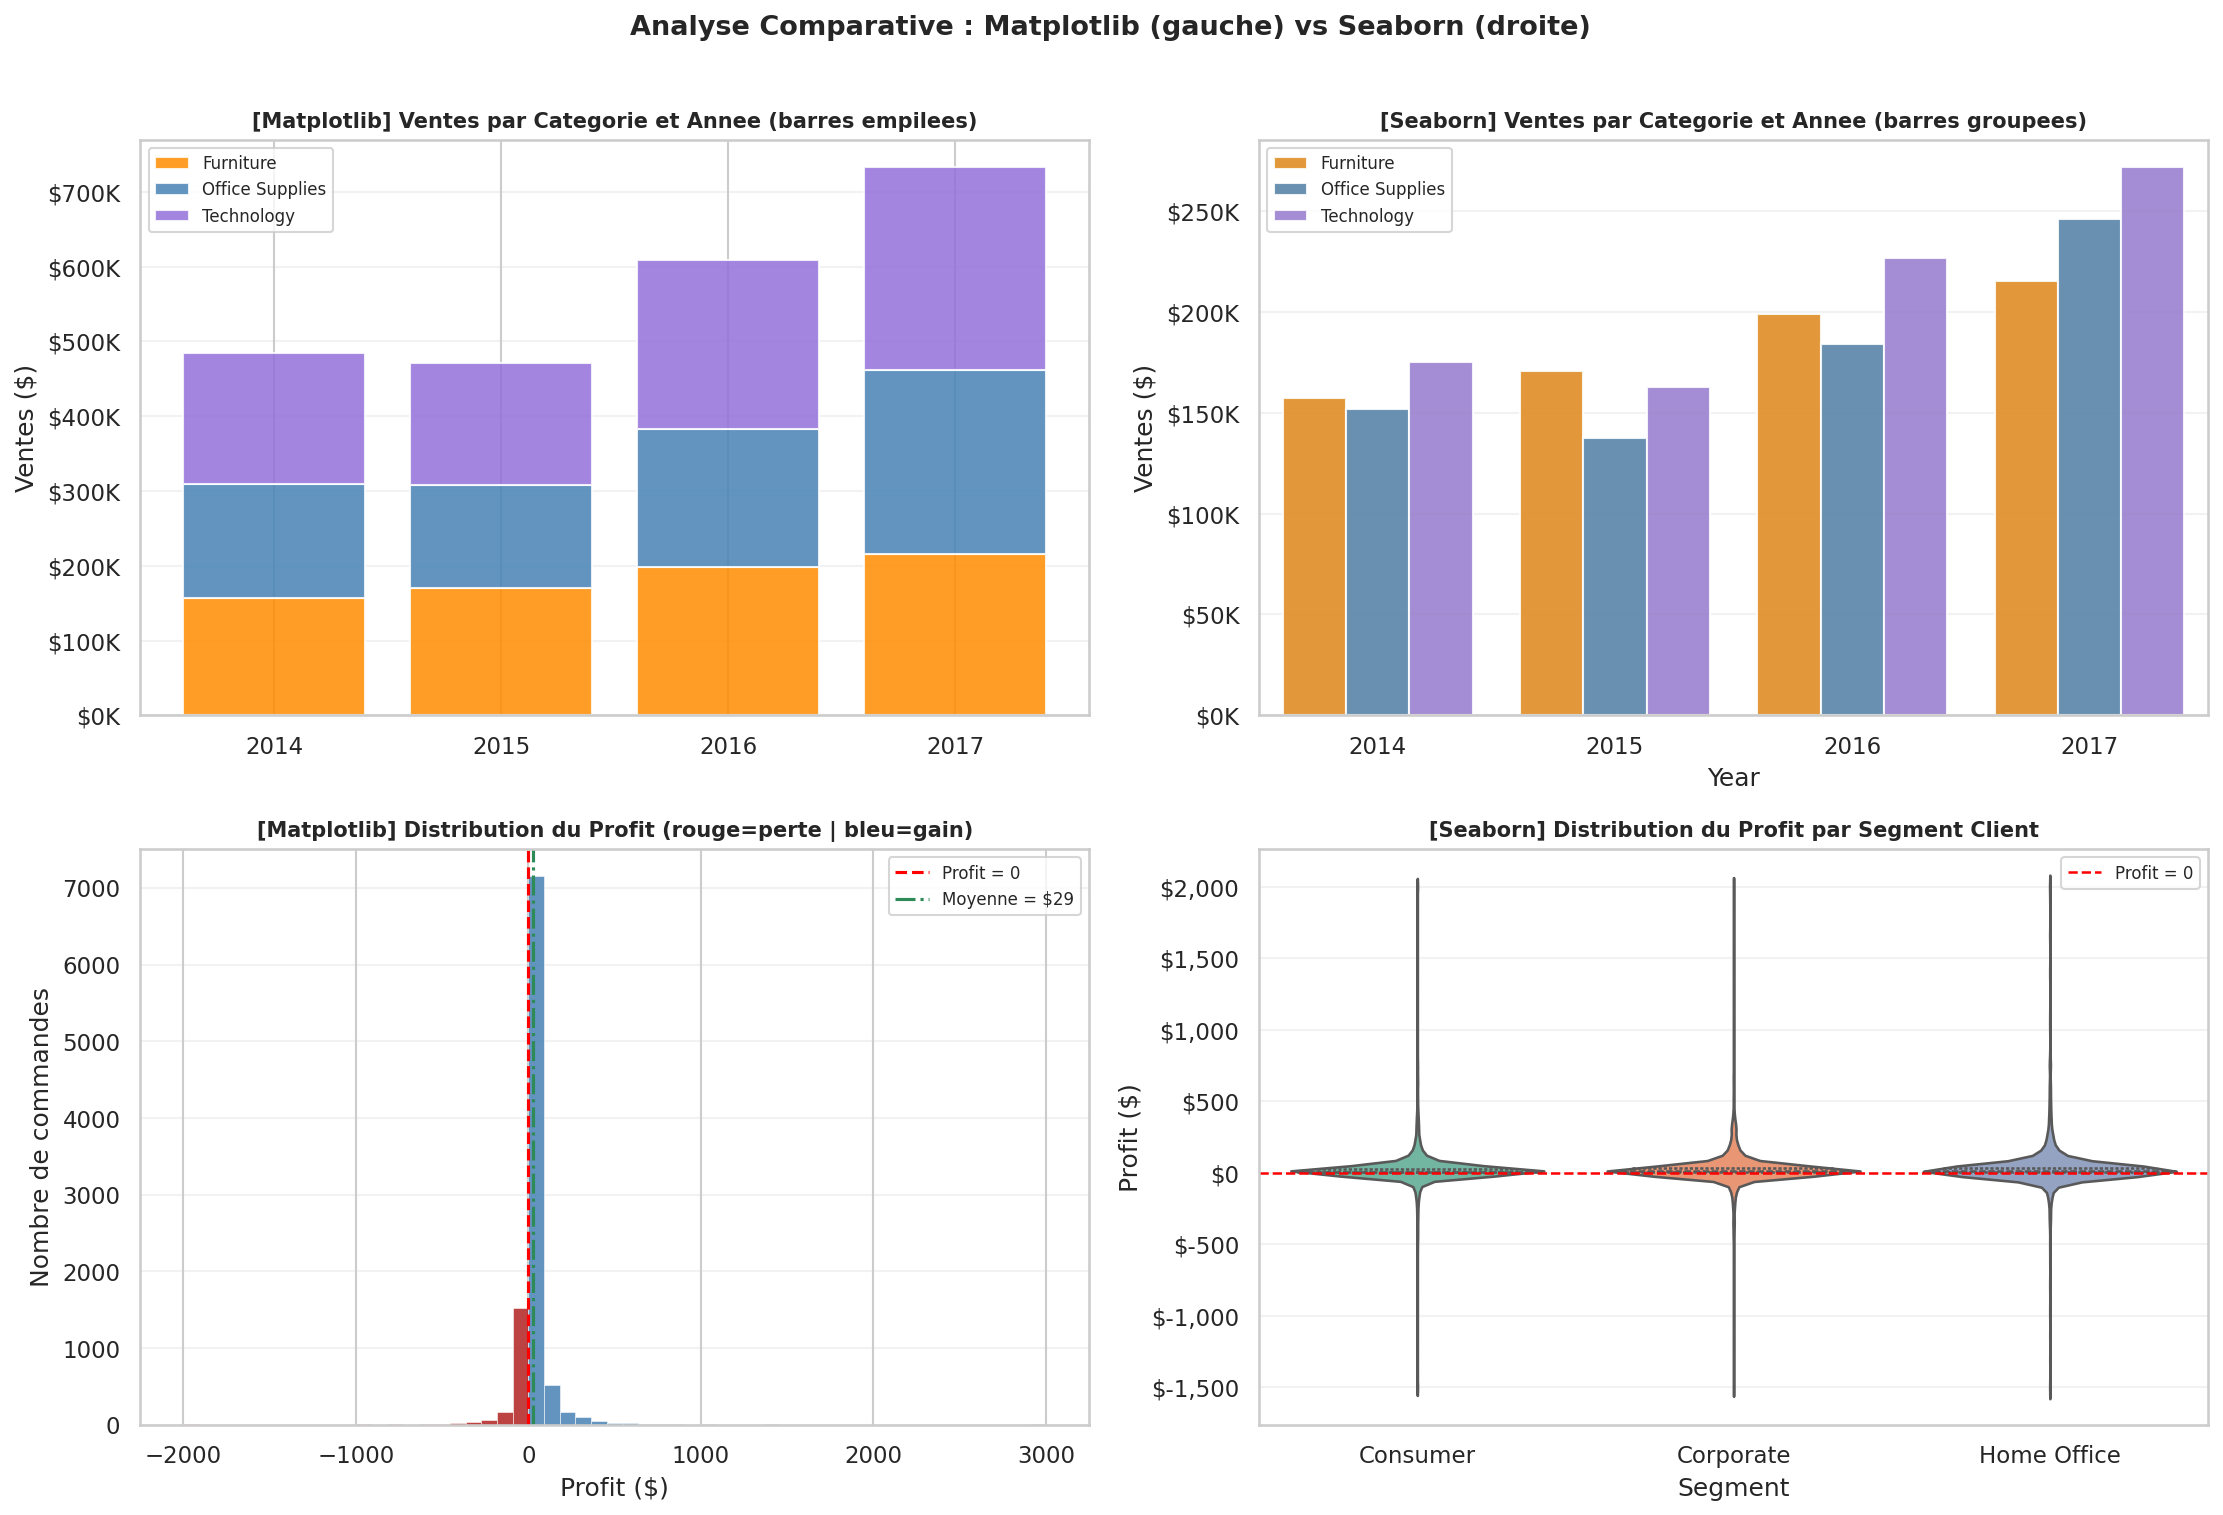

In [ ]:
# Resultat : Comparaison Matplotlib vs Seaborn

**Observations :**
- Matplotlib (barres empilees) : plus de code mais vue globale des totaux par annee
- Seaborn (barres groupees) : moins de code, plus facile de comparer les categories entre annees
- L'histogramme Matplotlib permet de colorer differemment les zones de perte et de gain
- Le violin plot Seaborn montre la forme entiere de la distribution (plus informatif qu'un boxplot simple)
- La plupart des commandes sont profitables, mais il existe une queue de distribution negative


### Bonus - Heatmaps Seaborn : Correlations et Saisonnalite

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Heatmap 1 : matrice de correlation ----
# On calcule la correlation entre toutes les paires de variables numeriques
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

# sns.heatmap affiche un tableau colore des correlations
# annot=True affiche les valeurs dans chaque cellule
# cmap='coolwarm' : bleu = correlation negative, rouge = correlation positive
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0],
            linewidths=0.5, vmin=-1, vmax=1, square=True, annot_kws={'size':11})
axes[0].set_title('[Seaborn] Matrice de Correlation', fontsize=12, fontweight='bold')

# ---- Heatmap 2 : ventes mensuelles par categorie ----
# pivot_table : reorganise les donnees comme un tableau croise dynamique
pivot = df.pivot_table(values='Sales', index='Category', columns='Month',
                       aggfunc='sum').fillna(0)
pivot.columns = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']

# On divise par 1000 pour afficher en K$
sns.heatmap(pivot / 1e3, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label':'Ventes (K$)'}, annot_kws={'size':9})
axes[1].set_title('[Seaborn] Ventes Mensuelles par Categorie (K$)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

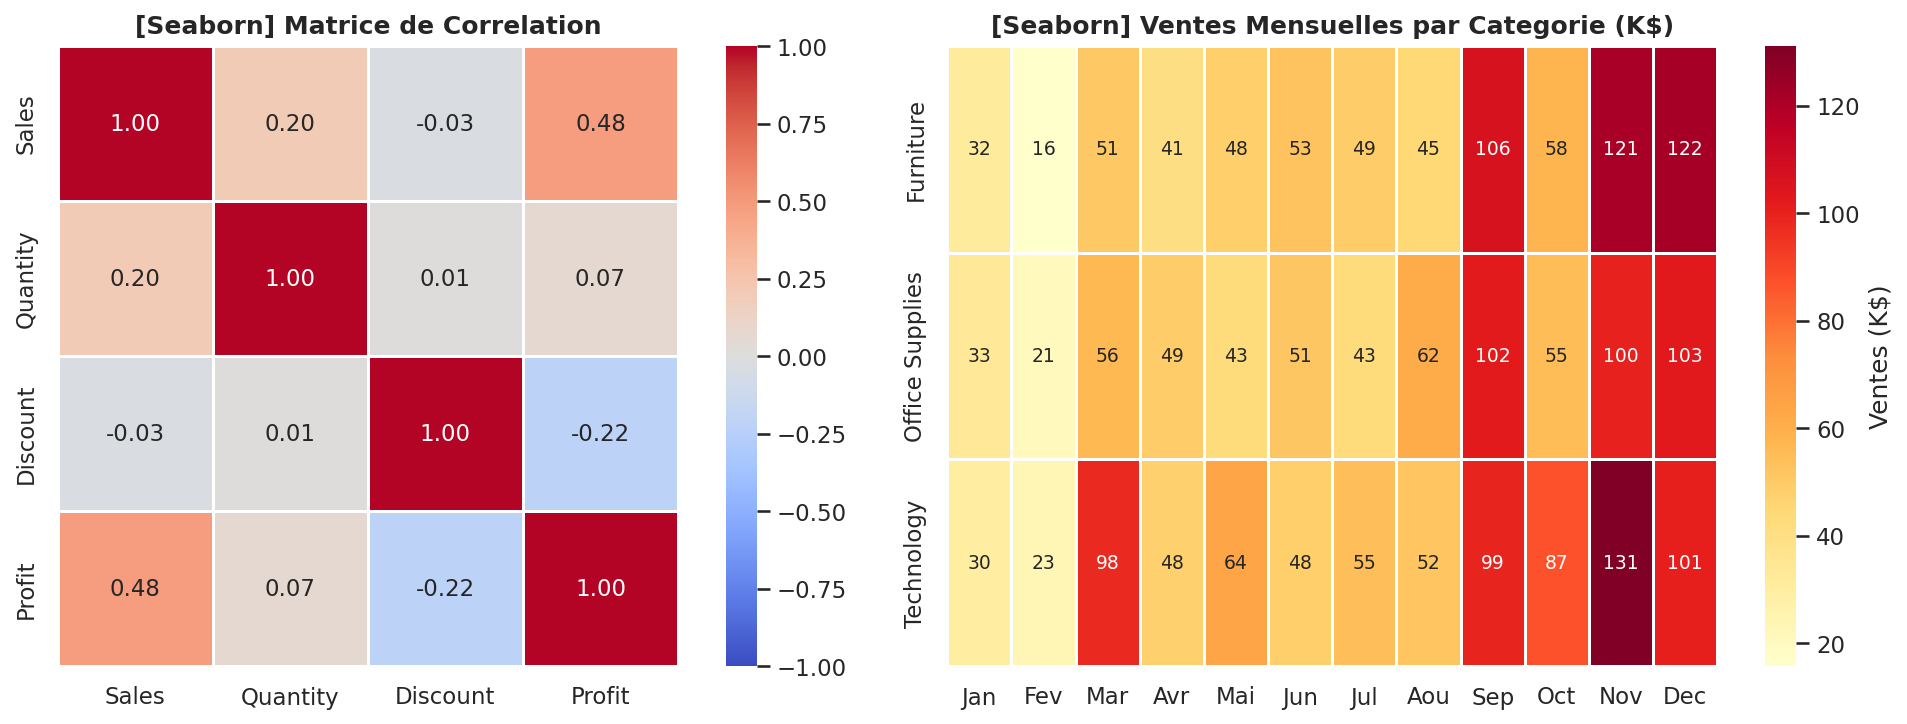

**Observations :**
- La matrice de correlation confirme : Discount et Profit sont negativement correles (r = -0.22)
- Sales et Profit sont positivement correles (r = +0.48), ce qui est logique
- La heatmap mensuelle revele la saisonnalite : novembre et decembre sont les meilleurs mois pour toutes les categories
- La Technologie genere les ventes les plus elevees, notamment en fin d'annee
- `pivot_table()` est l'equivalent Python d'un tableau croise dynamique Excel


---
## Partie 4 - Bilan Comparatif : Quand Utiliser Quoi ?

| Critere | Matplotlib | Seaborn |
|---|---|---|
| Lignes de code | Plus nombreuses | Moins nombreuses |
| Controle visuel | Total (chaque element) | Partiel (via matplotlib) |
| Graphiques statistiques | A coder soi-meme | Integres (regplot, violinplot...) |
| Courbe d'apprentissage | Plus longue | Plus rapide |
| Personnalisation avancee | Excellente | Bonne |
| Ideal pour | Rendus sur mesure | Analyse exploratoire rapide |

### Recommandation pratique

- Debuter avec **Seaborn** pour explorer rapidement les donnees (moins de code, joli par defaut)
- Affiner avec **Matplotlib** pour personnaliser les graphiques destines a etre partages
- En pratique, les deux se combinent : Seaborn cree, Matplotlib finalise


---
## Conclusions et Principaux Enseignements

**Sur les donnees :**
1. Les ventes ont augmente de 51% entre 2014 et 2017 (de $484K a $733K)
2. Le T4 (octobre-decembre) est systematiquement le meilleur trimestre
3. La Californie et New York sont les deux marches les plus importants et les plus rentables
4. Le Texas a un fort CA mais une marge negative : la politique de remises y est problematique
5. Au-dela de 20% de remise, la plupart des commandes deviennent deficitaires
6. Le Canon imageCLASS 2200 est le produit le plus vendu ($62K)

**Sur les outils :**
- Matplotlib et Seaborn sont complementaires
- Seaborn reduit considerablement la quantite de code necessaire pour des graphiques statistiques
- La maitrise de Matplotlib reste essentielle pour personaliser et finaliser les visualisations
